## CITS2402 - Introduction to Data Science - Project.

### Comparing Demographic Trends in Australian and New Zealand Census Data

**Date:** October 2026.

## Declaration

This declaration should be completed and remain attached to the top of your submission.

*I/we am/are aware of the University’s [policy on academic conduct](https://www.uwa.edu.au/policy/-/media/project/uwa/uwa/policy-library/policy/student-administration/academic-integrity/academic-integrity-policy.doc) and I declare that this assignment is entirely the work of the author(s) listed below and that suitable acknowledgement has been made for any sources of information used in preparing it. I have retained a copy for my own records.*

- Name 1: Hayden Browne
- Student ID 1: 23114898
- Name 2: Even Maelum
- Student ID 2: 25560058
- Date: 2 October 2026


## Introduction

Australia and New Zealand are neighbouring countries built largely on migration, and they are closely linked by trans-Tasman movement in both directions. More than a quarter of each population was born overseas. *Where* migrants come from, *how old* they are and *how long* they have been settled shapes demand for schools, jobs, housing and aged care, and shows how each country's migration history differs.

Comparing the two countries is not straightforward. Their most recent censuses were two years apart (Australia in August 2021, New Zealand in March 2023), on either side of the COVID-19 border closures, and the two statistics agencies publish birthplace, age and arrival data in different formats and categories.

**Research question:**

### How do the overseas-born populations of Australia and New Zealand differ by country of birth and age, and what do the available arrival data reveal about their settlement histories?

**Approach.** We harmonise the published census tables from both countries and compare them as shares, not counts. The analysis moves from the overall size of the overseas-born population, to the largest birthplaces, their age profiles and their arrival times. It then tests whether recent arrival and younger age go together in both countries, and uses k-means clustering to group birthplaces with similar profiles across the two countries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

australia_data_path = Path("Australia_Data")
new_zealand_data_path = Path("New_Zealand_Data")

au_census, nz_census = "Australia 2021", "New Zealand 2023"
country_colours = {au_census: "tab:orange", nz_census: "tab:blue"} # Same colour for each census in every plot

top_n = 10 # Birthplaces shown in the ranking
min_group_size = 10_000 # Smaller birthplace groups give noisy percentages
n_clusters = 3 # Chosen from the elbow and silhouette plots in Section 7
random_state = 42 # Fixed so k-means gives the same result every run

## Data

The notebook expects the data in two folders next to it, `Australia_Data/` and `New_Zealand_Data/`. Keep this folder structure when unzipping or uploading to Colab.

### Australian data
The Australian data is from the ABS 2021 Census [General Community Profile (GCP) DataPack](https://www.abs.gov.au/census/find-census-data/datapacks) [1].

**How to get it:** ABS Census page → *Find Census data* → *Census data tools* → *DataPacks* → Census year **2021**, DataPack type **General Community Profile**, Geography **Australia** → download the ZIP. From its `2021 Census GCP Australia for AUS` folder, copy these CSVs into `Australia_Data/`:

| Table | Files | Content |
|---|---|---|
| G09 | `2021Census_G09A_AUS_AUS.csv` … `G09H` | Country of birth × age × sex |
| G10 | `2021Census_G10A_AUS_AUS.csv` … `G10C` | Country of birth × year of arrival |
| G44 | `2021Census_G44_AUS_AUS.csv` | Usual address 1 year ago |
| G45 | `2021Census_G45_AUS_AUS.csv` | Usual address 5 years ago |

Each file is one row (the whole of Australia) with one column per category, and the tables are split over several files (e.g. G09A-G09H) because of their width. The unit is **persons counted at their usual residence on census night (10 August 2021)**. Counts describe people living in Australia at the census, not all past arrivals or departures.

In [44]:
def load_au(table):
    """Read every part of an ABS table (e.g. G09A-G09H) and join them into one row."""
    files = sorted(australia_data_path.glob(f"2021Census_{table}*_AUS_AUS.csv"))
    result = pd.read_csv(files[0])
    for file in files[1:]:
        result = pd.merge(result, pd.read_csv(file), on="AUS_CODE_2021")
    return result

### New Zealand data
The New Zealand data is from the 2023 Census on Stats NZ's [Aotearoa Data Explorer](https://explore.data.stats.govt.nz/) [2].

**How to get it:** search the Data Explorer for each dataset ID below, set **Census year = 2023** and **Area = Total - New Zealand by regional council**, leave the other filters as listed, then *Download* → *Filtered data in tabular text (CSV)*. The files were renamed as shown and saved in `New_Zealand_Data/`.

| Dataset ID | Saved as | Content | Other filters |
|---|---|---|---|
| CEN23_ECI_006 | `NZ2023_birthplace_age_CEN23_ECI_006.csv` | Birthplace × age | All birthplaces, all ages |
| CEN23_ECI_005 | `NZ2023_birthplace_years_since_arrival_CEN23_ECI_005.csv` | Birthplace × years since arrival (overseas-born only) | All birthplaces and arrival categories, Age and Gender = Total |
| CEN23_LOC_007 | `NZ2023_usual_residence_1yr_ago_CEN23_LOC_007.csv` | Usual residence 1 year ago | Ethnicity and Gender = Total |
| CEN23_LOC_005 | `NZ2023_usual_residence_5yr_ago_CEN23_LOC_005.csv` | Usual residence 5 years ago | Ethnicity and Gender = Total |

Unlike the ABS files, these are in "long" format: one row per combination of categories, with the count in `OBS_VALUE`. Birthplaces are coded hierarchically (e.g. `B04` North-West Europe → `B0401` England), and regional subtotals sit in the same column as countries. The unit is the **census usually resident population count on census night (7 March 2023)**.

In [ ]:
def load_nz(table):
    """Read a Stats NZ table, keeping the 2023 census and the whole-of-NZ total."""
    file = next(new_zealand_data_path.glob(f"NZ2023_*_CEN23_{table}.csv"))
    result = pd.read_csv(file, dtype=str) # Read as text: age codes "01" (0-4 years) and "1" (under 15) are different
    result["OBS_VALUE"] = pd.to_numeric(result["OBS_VALUE"])
    return result[(result["Census year"] == "2023") & result["Area"].str.startswith("Total")]


# The same birthplace is spelled differently in G09, G10 and the NZ tables
country_names = {
    "China exc SARs Taiwan": "China", "China, People's Republic of": "China",
    "Hong Kong SAR Ch": "Hong Kong", "Hong Kong SAR China": "Hong Kong", "Hong Kong (Special Administrative Region)": "Hong Kong",
    "Korea South": "South Korea", "Korea Republic South": "South Korea", "Korea, Republic of": "South Korea",
    "USA": "United States", "United States of America": "United States",
    "Viet Nam": "Vietnam", "PNG": "Papua New Guinea", "Bosnia Herzegov": "Bosnia and Herzegovina",
}

def clean_name(name):
    """Give a birthplace one readable name that is shared by both countries."""
    name = name.replace("_", " ")
    return country_names.get(name, name)


def nz_by_birthplace(data, category):
    """Pivot a Stats NZ table to one row per country of birth and one column per category."""
    code_column = [name for name in data.columns if name.startswith("CEN23_BIR")][0]
    names = data.groupby(code_column)["Birthplace"].first()

    # Keep NZ-born (A), Australia (B01) and single countries like B0401, not regions or "Other" groups
    keep = [code for code, name in names.items()
            if code in ("A", "B01") or (len(code) == 5 and not name.startswith("Other"))]

    grid = data.pivot_table(index=code_column, columns=category, values="OBS_VALUE", aggfunc="sum")
    return grid.loc[keep].rename(index=lambda code: clean_name(names[code]))


def to_shares(counts):
    """Turn each row of counts into percentages of the row total."""
    return counts.div(counts.sum(axis=1), axis=0) * 100


def regroup(counts, groups):
    """Add count columns up into new groups and return each row as percentages."""
    grouped = pd.DataFrame({group: counts[columns].sum(axis=1) for group, columns in groups.items()})
    return to_shares(grouped)


def plot_country_pair(au_data, nz_data, title, ylabel, legend_title):
    """Draw matching stacked bar charts for Australia and New Zealand side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, data, census in zip(axes, [au_data, nz_data], [au_census, nz_census]):
        data.plot.bar(stacked=True, ax=ax, colormap="viridis", legend=False, width=0.8)
        ax.set_title(census)
        ax.set_xlabel("Country of birth")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    axes[0].set_ylabel(ylabel)
    axes[1].legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Making the two censuses comparable: assumptions and simplifications

The two censuses measure the same ideas in different ways. These are the choices we made and why:

1. **Different years.** Australia is 2021 and New Zealand is 2023. We compare them as each country's most recent census, but they are two years apart and sit on different sides of the COVID-19 border closures (Australia's census was taken while its borders were closed).
2. **Shares, not counts.** Australia has about five times as many residents, so all comparisons use percentages of the relevant group.
3. **"Not stated" is left out of denominators** for age, arrival and previous address, so shares are of people who answered. Overseas-born shares are of *all* residents, so the 5.3% (AU) and 0.8% (NZ) with birthplace not stated are counted as not overseas-born.
4. **Birthplace names are matched by hand.** The same country is spelled differently across G09, G10 and Stats NZ (e.g. `China_exc_SARs_Taiwan`, "China, People's Republic of"). The `country_names` dictionary maps them to one name.
5. **Only single countries are ranked.** ABS "Elsewhere", Stats NZ regions (e.g. "North-West Europe") and "Other ..." groups are dropped. G09 lists 49 named countries and the NZ table 78, so smaller birthplaces in Australia are not available individually.
6. **United Kingdom vs England.** G10 (arrival) only has the United Kingdom as a whole, so for arrivals we add NZ's England, Scotland, Wales, Northern Ireland, Channel Islands and "UK not further defined" together. For age (G09) we use England, which both countries publish.
7. **Age bands.** NZ publishes 5-year bands, which add up exactly to the ABS bands (0-4, 5-14, 15-24, 25-44, 45-54, 55-64, 65-74, 75-84, 85+).
8. **Arrival time.** The ABS asks for *year of arrival* and Stats NZ for *years since arrival*. We convert both to years before the census: 0-4, 5-9, 10-19 and 20+. The NZ bins are exact. The ABS bins are approximate because ABS groups years as 2011-15 and 2001-10, so its "5-9 years" is really 2011-2016 (5-10 years) and its "10-19 years" is 2001-2010 (11-20 years). "Recent arrival" means the last 5 years in both countries (AU 2017-2021, NZ less than 1 year to 4 years). For the timeline plot, multi-year periods are spread evenly across their years, and NZ's "years since arrival" is mapped to calendar years (e.g. "1 year" ≈ 2021) even though NZ's census year runs from March.
9. **Random rounding.** Stats NZ randomly rounds counts to base 3 for confidentiality [5], and a handful of tiny cells are suppressed. Shares are therefore computed from the sum of the categories used, which may differ from the published total by a few people.
10. **Small groups are left out of the scatter and clustering.** Only birthplace groups with at least 10,000 residents are used (`min_group_size`), because percentages for very small groups are noisy.
11. **Previous address.** Categories are merged to what both censuses share: *same address*, *elsewhere in the country* (ABS same/different SA2; NZ any other NZ address), *overseas* and *other or not stated* (ABS "moved, location not stated"; NZ "no fixed abode"). People not yet born are excluded in both.
12. **Group-level analysis only.** All tables are aggregates, so relationships between groups (e.g. recent arrival and age) cannot be read as facts about individuals.

## Analysis

### 1. How large is the overseas-born population?
We first compare the overall size of the overseas-born population in each country. Australia gives this directly in G09 (all residents minus Australia-born minus not stated). Stats NZ publishes "Overseas" as its own birthplace category.

In [46]:
# Residents in Australia with a stated overseas birthplace

g09_df = load_au("G09")
g09_values = g09_df.iloc[0]

au_residents = g09_values["P_Tot_Tot"]
au_not_stated = g09_values["P_COB_NS_Tot"]
au_overseas = au_residents - g09_values["P_Australia_Tot"] - au_not_stated

In [ ]:
# Residents in New Zealand with a stated overseas birthplace, compared with Australia

nz_age_df = load_nz("ECI_006")
nz_totals = nz_age_df[nz_age_df["Age"] == "Total - age"].set_index("Birthplace")["OBS_VALUE"]

nz_residents = nz_totals["Total - birthplace"]
nz_not_stated = nz_totals["Not elsewhere included"] # Stats NZ's label for birthplace not stated
nz_overseas = nz_totals["Overseas"]

overseas_summary = pd.DataFrame({
    au_census: [au_residents, au_overseas, au_not_stated],
    nz_census: [nz_residents, nz_overseas, nz_not_stated],
}, index=["All residents", "Stated overseas birthplace", "Birthplace not stated"])

share_columns = [f"{au_census} (%)", f"{nz_census} (%)"]
for census, share_column in zip([au_census, nz_census], share_columns):
    overseas_summary[share_column] = overseas_summary[census] / overseas_summary.loc["All residents", census] * 100

overseas_summary = overseas_summary[[au_census, share_columns[0], nz_census, share_columns[1]]]
overseas_summary.style.format("{:,.0f}").format("{:.1f}", subset=share_columns).set_caption("Overseas-born residents (% of all residents)")

**Result.** The two countries are strikingly similar in scale: **27.7%** of Australian residents (7.04 million) and **28.6%** of New Zealand residents (1.43 million) had a stated overseas birthplace. The main difference is data quality. Birthplace was not stated for **5.3%** of Australians but only **0.8%** of New Zealanders, partly because Stats NZ fills in missing answers from administrative records [6]. If most of Australia's not-stated group were overseas-born, the true Australian share would be higher than 27.7%, so the small gap should not be over-read.

### 2. Where were overseas-born residents born?
Next we rank named birthplaces in each country, as a share of all residents so the two countries can be read on the same scale. The NZ table has no sex breakdown, so only totals are compared.

In [48]:
# Named overseas birthplaces in Australia, as a share of all residents

exclude = {"Tot", "Australia", "Elsewhere", "COB_NS"} # Totals, Australia-born and grouped categories
au_countries = [name[2:-4] for name in g09_df.columns
                if name.startswith("P_") and name.endswith("_Tot") and name[2:-4] not in exclude]

au_birthplaces = pd.Series({clean_name(country): g09_values[f"P_{country}_Tot"] for country in au_countries})
au_birthplaces = (au_birthplaces / au_residents * 100).sort_values(ascending=False)

In [49]:
# Named overseas birthplaces in New Zealand, as a share of all residents

nz_age_grid = nz_by_birthplace(nz_age_df, "Age")

nz_birthplaces = nz_age_grid["Total - age"].drop("New Zealand")
nz_birthplaces = (nz_birthplaces / nz_residents * 100).sort_values(ascending=False)

In [ ]:
# Ten largest named overseas birthplaces in each country

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, (census, shares) in zip(axes, [(au_census, au_birthplaces), (nz_census, nz_birthplaces)]):
    shares.head(top_n).sort_values().plot.barh(ax=ax, color=country_colours[census])
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=2)
    ax.set_title(census)
    ax.set_xlabel("Share of all residents (%)")
    ax.set_ylabel("")
axes[0].set_ylabel("Country of birth")
fig.suptitle(f"{top_n} largest named overseas birthplaces")
plt.tight_layout()
plt.show()

**Result.** Five birthplaces appear in both top tens: **England, India, China, the Philippines and South Africa**. England is the largest in both (3.6% of Australian residents, 4.2% of New Zealanders). The trans-Tasman link is also strong: New Zealand is the 4th largest birthplace in Australia (2.1%, about 530,000 people) and Australia is 6th in New Zealand (1.7%, about 86,000).

The differences reflect each country's region. New Zealand's list includes **Fiji and Samoa**, which reflects its long-standing Pacific migration. Australia's includes **Vietnam, Malaysia, Italy and Sri Lanka**, showing older post-war European and South-East Asian migration. New Zealand's overseas-born population is also more concentrated: its top ten make up about **68%** of the overseas-born, compared with **55%** in Australia.

*Caveat:* G09 names only 49 countries, so Australia's share outside the top ten is partly hidden in "Elsewhere".

### 3. How old are the birthplace groups?
We compare the age profile of the largest shared birthplace groups, with each country's own locally-born population included as a reference.

In [ ]:
# Age distribution of each birthplace group in Australia

age_labels = ["0-4", "5-14", "15-24", "25-44", "45-54", "55-64", "65-74", "75-84", "85+"]
au_age_columns = ["0_4", "5_14", "15_24", "25_44", "45_54", "55_64", "65_74", "75_84", "85ov"]

au_age_grid = pd.DataFrame(
    [[g09_values[f"P_{country}_{age}"] for age in au_age_columns] for country in au_countries + ["Australia"]],
    index=[clean_name(country) for country in au_countries + ["Australia"]], columns=age_labels)
au_age = to_shares(au_age_grid)

In [52]:
# Age distribution of each birthplace group in New Zealand

# NZ publishes 5-year bands, so add them up to match the ABS bands
nz_age_bands = {
    "0-4": ["0-4 years"], "5-14": ["5-9 years", "10-14 years"], "15-24": ["15-19 years", "20-24 years"],
    "25-44": ["25-29 years", "30-34 years", "35-39 years", "40-44 years"], "45-54": ["45-49 years", "50-54 years"],
    "55-64": ["55-59 years", "60-64 years"], "65-74": ["65-69 years", "70-74 years"],
    "75-84": ["75-79 years", "80-84 years"], "85+": ["85-89 years", "90 years and over"],
}
nz_age = regroup(nz_age_grid, nz_age_bands)

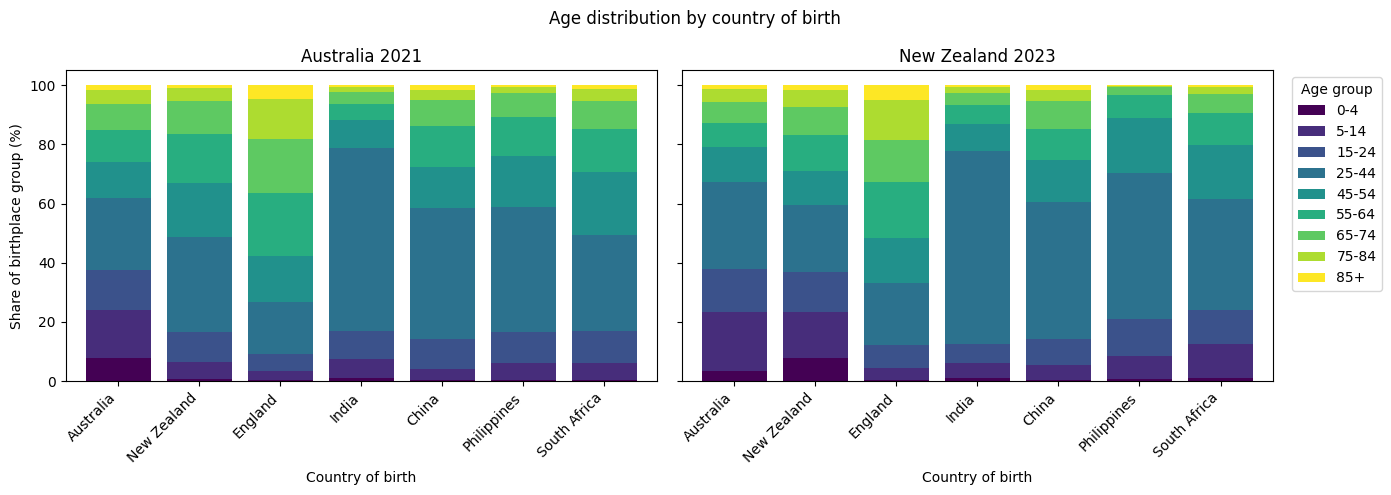

,"Aged 25-44, AU (%)","Aged 25-44, NZ (%)","Aged 65+, AU (%)","Aged 65+, NZ (%)"
Australia,24.4,29.3,15.1,12.8
New Zealand,31.9,22.6,16.4,16.9
England,17.7,20.9,36.5,32.6
India,61.7,65.2,6.3,6.7
China,44.4,46.5,13.9,14.7
Philippines,42.0,49.3,10.6,3.4
South Africa,32.5,37.3,14.9,9.3


In [53]:
# Age distribution comparison of selected birthplace groups

age_countries = ["Australia", "New Zealand", "England", "India", "China", "Philippines", "South Africa"]
plot_country_pair(au_age.loc[age_countries], nz_age.loc[age_countries],
                  "Age distribution by country of birth", "Share of birthplace group (%)", "Age group")

# Working-age and older shares side by side
age_summary = pd.DataFrame({
    "Aged 25-44, AU (%)": au_age.loc[age_countries, "25-44"],
    "Aged 25-44, NZ (%)": nz_age.loc[age_countries, "25-44"],
    "Aged 65+, AU (%)": au_age.loc[age_countries, ["65-74", "75-84", "85+"]].sum(axis=1),
    "Aged 65+, NZ (%)": nz_age.loc[age_countries, ["65-74", "75-84", "85+"]].sum(axis=1),
})
age_summary.style.format("{:.1f}").set_caption("Share of each birthplace group by age (%)")

**Result.** Age profiles depend much more on *where people were born* than on *which country they moved to*. India-born residents are the clearest example: **61.7%** (AU) and **65.2%** (NZ) are aged 25-44, and only about 6-7% are 65+ in either country. England-born residents are the opposite: roughly a third are 65+ in both countries (36.5% AU, 32.6% NZ).

The trans-Tasman groups are the most interesting difference:
- **NZ-born in Australia** are mostly working-age adults: 31.9% aged 25-44 and only **6.6% under 15**.
- **Australia-born in New Zealand** include many children: **23.5% are under 15**, almost exactly the same as the NZ-born (23.2%). One plausible reading (which these tables cannot prove) is that many are children born in Australia to New Zealand families who later moved back.

The Philippines and South Africa groups are younger in New Zealand (65+: 3.4% vs 10.6%, and 9.3% vs 14.9%), which matches their more recent arrival in NZ (Section 4).

### 4. When did they arrive?
Arrival time shows whether a birthplace group is newly arrived or long settled. Both countries are converted to *years before the census* (see assumption 8). Locally-born people have no arrival year, so each panel shows the other trans-Tasman country instead. A timeline of arrivals per year for *all* overseas-born residents then shows how migration changed over time.

In [ ]:
# Arrival periods of overseas-born people living in Australia

g10_df = load_au("G10")
arrival_periods = ["Before 1951", "1951-60", "1961-70", "1971-80", "1981-90", "1991-2000", "2001-10", "2011-15",
                   "2016", "2017", "2018", "2019", "2020", "2021"]

# G10 has 16 columns per country (14 periods, not stated, total), and names vary, so use positions
g10_values = g10_df.drop(columns="AUS_CODE_2021").iloc[0]
g10_names = [clean_name(name.rsplit("_", 1)[0]) for name in g10_values.index[15::16]]
g10_grid = pd.DataFrame(g10_values.to_numpy().reshape(-1, 16), index=g10_names, columns=arrival_periods + ["Not stated", "Total"])
au_arrival_grid = g10_grid.drop(["Born elsewhere", "Tot"])

# Years before the census, to line up with NZ's "years since arrival"
au_arrival_bins = {"0-4 years": ["2017", "2018", "2019", "2020", "2021"], "5-9 years": ["2011-15", "2016"],
                   "10-19 years": ["2001-10"], "20+ years": arrival_periods[:6]}
au_arrival = regroup(au_arrival_grid, au_arrival_bins)

In [55]:
# Years since arrival of overseas-born people living in New Zealand

nz_arrival_df = load_nz("ECI_005")
nz_arrival_grid = nz_by_birthplace(nz_arrival_df, "Years since arrival in New Zealand")

# G10 only has the UK as a whole, so add up NZ's UK countries
uk_parts = ["England", "Scotland", "Wales", "Northern Ireland", "Channel Islands", "United Kingdom (not further defined)"]
nz_arrival_grid.loc["United Kingdom"] = nz_arrival_grid.loc[uk_parts].sum()

nz_arrival_bins = {"0-4 years": ["Less than one year", "1 year", "2 years", "3 years", "4 years"],
                   "5-9 years": ["5-9 years"], "10-19 years": ["10-19 years"], "20+ years": ["20 years or more"]}
nz_arrival = regroup(nz_arrival_grid, nz_arrival_bins)

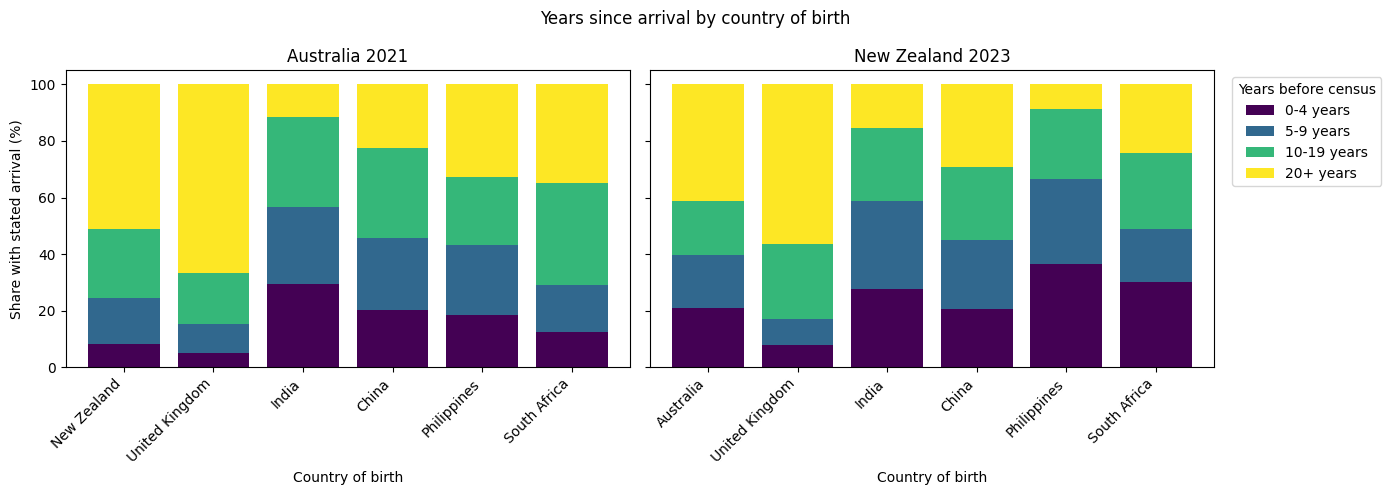

,"Last 5 years, AU (%)","Last 5 years, NZ (%)","20+ years, AU (%)","20+ years, NZ (%)"
New Zealand,8.1,-,51.0,-
Australia,-,21.0,-,41.2
United Kingdom,4.9,7.9,66.6,56.4
India,29.3,27.6,11.6,15.3
China,20.2,20.4,22.6,29.1
Philippines,18.3,36.5,32.7,8.5
South Africa,12.3,30.0,34.8,24.1


In [56]:
# Years since arrival comparison of selected birthplace groups

arrival_countries = ["New Zealand", "Australia", "United Kingdom", "India", "China", "Philippines", "South Africa"]
plot_country_pair(au_arrival.reindex(arrival_countries).dropna(), nz_arrival.reindex(arrival_countries).dropna(),
                  "Years since arrival by country of birth", "Share with stated arrival (%)", "Years before census")

arrival_summary = pd.DataFrame({
    "Last 5 years, AU (%)": au_arrival["0-4 years"], "Last 5 years, NZ (%)": nz_arrival["0-4 years"],
    "20+ years, AU (%)": au_arrival["20+ years"], "20+ years, NZ (%)": nz_arrival["20+ years"],
}).reindex(arrival_countries)
arrival_summary.style.format("{:.1f}", na_rep="-").set_caption("Share of each birthplace group by years since arrival (%)")

In [ ]:
# Arrivals per year for all overseas-born residents, as a time series

au_period_years = {"1951-60": range(1951, 1961), "1961-70": range(1961, 1971), "1971-80": range(1971, 1981),
                   "1981-90": range(1981, 1991), "1991-2000": range(1991, 2001), "2001-10": range(2001, 2011),
                   "2011-15": range(2011, 2016)}
for year in range(2016, 2022):
    au_period_years[str(year)] = [year] # G10 gives single years from 2016

# NZ's census was in March, so "less than one year" is roughly 2022, "1 year" 2021, and so on
nz_period_years = {"Less than one year": [2022], "1 year": [2021], "2 years": [2020], "3 years": [2019], "4 years": [2018],
                   "5-9 years": range(2013, 2018), "10-19 years": range(2003, 2013)}

def arrivals_per_year(counts, period_years, residents):
    """Spread each arrival period evenly over its years, as a share of all residents."""
    per_year = {year: counts[period] / len(years) for period, years in period_years.items() for year in years}
    return pd.Series(per_year).sort_index() / residents * 100

au_all_arrivals = g10_grid.loc["Tot"] # G10's total row covers every overseas birthplace
nz_all_arrivals = nz_arrival_df[nz_arrival_df["Birthplace"] == "Overseas"].set_index("Years since arrival in New Zealand")["OBS_VALUE"]

timeline = pd.DataFrame({au_census: arrivals_per_year(au_all_arrivals, au_period_years, au_residents),
                         nz_census: arrivals_per_year(nz_all_arrivals, nz_period_years, nz_residents)})

fig, ax = plt.subplots(figsize=(11, 5))
for census in timeline.columns:
    ax.plot(timeline.index, timeline[census], drawstyle="steps-mid", color=country_colours[census], label=census, linewidth=1.5)
ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.2, label="COVID-19 border closures (approx.)")
ax.set_title("Overseas-born residents by year of arrival")
ax.set_xlabel("Year of arrival (multi-year periods spread evenly)")
ax.set_ylabel("Arrivals per year still living there\n(% of all residents)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result.** The United Kingdom-born are the longest settled in both countries: most arrived 20+ years before the census (66.6% AU, 56.4% NZ), and very few in the last 5 years (4.9% and 7.9%). India-born are the most recent in Australia and similar in NZ, with 27-29% arriving in the last 5 years.

New Zealand has had more *recent* migration from several countries. **36.5%** of Philippines-born residents in NZ arrived in the last 5 years, against 18.3% in Australia, and South Africa shows the same pattern (30.0% vs 12.3%). The trans-Tasman flows also differ: only **8.1%** of NZ-born in Australia arrived recently (half have been there 20+ years), while **21.0%** of Australia-born in NZ arrived recently.

**The timeline shows how much COVID-19 matters.** Australia closed its border in March 2020 and did not reopen to most visa holders until February 2022 [7, 8]. New Zealand closed in March 2020 and fully reopened at the end of July 2022 [9]. In both countries, arrivals still living there rise steadily towards the census, partly because more recent arrivals have had less time to die or leave again. Then they fall sharply during the border closures. In Australia they drop from about 322,000 in 2019 (1.3% of residents) to 128,000 in 2020 and 39,000 in the first part of 2021. In New Zealand only about 16,000-22,000 arrived in 2020-2021, but about 109,000 (2.2% of residents) arrived in the final year before the March 2023 census, after borders reopened. Relative to its population, NZ's post-reopening year is about 1.7 times Australia's pre-COVID peak.

So "last 5 years" covers a partly closed window in both countries, and New Zealand's figure includes a post-reopening surge that Australia's 2021 census could not capture.

*Caveat:* these are people **still living in the country** at the census, not all historical arrivals. Older periods are reduced by deaths and people leaving again, so the timeline cannot be read as past migration levels.

### 5. Is recent arrival linked to a younger age profile in both countries?
Sections 3 and 4 suggest that recently arrived groups are younger. To test this across all groups, not just the selected ones, we build three measures for every birthplace group with at least 10,000 residents: share aged 25-44, share aged 65+, and share arrived in the last 5 years.

In [ ]:
# Age and arrival profile of each birthplace group in Australia

def build_features(age, arrival, sizes, min_size):
    """Combine age and arrival shares for birthplace groups found in both tables."""
    common = age.index.intersection(arrival.index)
    common = common[sizes.reindex(common) >= min_size]
    return pd.DataFrame({
        "Aged 25-44 (%)": age.loc[common, "25-44"],
        "Aged 65+ (%)": age.loc[common, ["65-74", "75-84", "85+"]].sum(axis=1),
        "Arrived in last 5 years (%)": arrival.loc[common, "0-4 years"],
    })

au_features = build_features(au_age, au_arrival, au_age_grid.sum(axis=1), min_group_size)

In [59]:
# Age and arrival profile of each birthplace group in New Zealand

nz_features = build_features(nz_age, nz_arrival, nz_age_grid["Total - age"], min_group_size)

In [ ]:
# Recent arrival against age profile, both countries on the same axes

recent_column = "Arrived in last 5 years (%)"
label_countries = ["India", "Nepal", "Philippines", "Italy", "England", "China", "New Zealand", "Australia"]
fit_rows = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, age_column in zip(axes, ["Aged 25-44 (%)", "Aged 65+ (%)"]):
    age_name = age_column.replace(" (%)", "")
    for census, features in [(au_census, au_features), (nz_census, nz_features)]:
        ax.scatter(features[recent_column], features[age_column], color=country_colours[census], alpha=0.7, label=census)
        for country in features.index.intersection(label_countries):
            ax.annotate(country, (features.loc[country, recent_column], features.loc[country, age_column]),
                        xytext=(4, 3), textcoords="offset points", fontsize=8, color=country_colours[census])

        # Straight-line fit (least squares) for each country
        slope, intercept = np.polyfit(features[recent_column], features[age_column], 1)
        x_line = np.linspace(0, features[recent_column].max(), 50)
        ax.plot(x_line, slope * x_line + intercept, color=country_colours[census], linestyle="--")
        fit_rows.append({"Census": f"{census} ({len(features)} groups)", "Age measure": age_name,
                         "Correlation": features[recent_column].corr(features[age_column]),
                         "Slope (points per +10 recent)": slope * 10})
    ax.set_xlabel("Arrived in the 5 years before the census (% of group)")
    ax.set_ylabel(f"{age_name} (% of group)")
    ax.set_title(f"Recent arrival vs share {age_name.lower()}")
    ax.set_ylim(bottom=0) # A share cannot be negative, even where a fitted line would go below zero
    ax.grid(alpha=0.3)
axes[0].legend(title="Census (dashed = linear fit)")
fig.suptitle("Each point is one birthplace group")
plt.tight_layout()
plt.show()

# Correlation and fitted slope for each country and age measure
fits = pd.DataFrame(fit_rows).set_index(["Age measure", "Census"])
fits.style.format("{:.2f}").set_caption("Linear fit of age share against share arrived in the last 5 years")

**Result.** The same pattern holds in both countries. Groups with more recent arrivals have a much larger working-age share (correlation **0.84** in Australia, **0.75** in NZ) and a smaller 65+ share (**-0.73** and **-0.81**). The fitted lines put a size on this: each extra 10 points of recent arrival goes with about **+14 points aged 25-44 in Australia but +11 in NZ**, and **-15 vs -10 points aged 65+**. So age profiles change less steeply with recent arrival in New Zealand, and its recently arrived groups are more mixed in age. This fits the family-based arrivals seen above, such as the many children among the Australia-born.

A straight line is only a rough summary. Shares cannot fall below 0%, so the Australian 65+ line would go negative beyond about 30% recent arrival, and the plot is cut at zero. **Nepal** (51% recent) is an outlier that flattens the Australian lines. Without it the Australian slopes would be even steeper (about +18 and -22), so the gap between the two countries does not come from this one group. Groups like Italy, Greece and the Netherlands (long settled, older) sit at one end. India, Nepal and the Philippines (recent, young adults) sit at the other.

New Zealand's points sit slightly to the right, so for a given age profile its groups tend to have more recent arrivals, which is consistent with the post-COVID surge in Section 4. The Australia-born in NZ are an outlier below the trend (21% recent but only 29% aged 25-44), because of the many children noted in Section 3.

*Caveats:* this compares group averages across 34 (AU) and 25 (NZ) groups, so it does not show that the recent arrivals themselves are 25-44. The sets of groups also differ slightly between the countries.

### 6. Where did residents live 1 and 5 years earlier?
The previous-address questions cover the *whole* population, not just the overseas-born. They show how much of each population arrived from overseas recently.

In [61]:
# Where Australian residents lived 1 and 5 years before the 2021 census

mobility_groups = ["Same address", "Elsewhere in the country", "Overseas", "Other or not stated"]

au_mobility = pd.DataFrame(columns=mobility_groups, dtype=float)
for label, table, years in [("1 year earlier", "G44", "1"), ("5 years earlier", "G45", "5")]:
    row = load_au(table).iloc[0]
    au_mobility.loc[label] = [
        row[f"Sme_Usl_ad_{years}_yr_ago_as_2021_P"],
        row[f"Dif_Usl_ad_{years}_yr_ago_Sme_SA2_P"] + row[f"Dif_Us_ad_{years}_ago_Dif_SA2_Tot_P"], # Same SA2 + other SA2
        row[f"Difnt_Usl_add_{years}_yr_ago_OS_P"],
        row[f"Difnt_Usl_add_{years}_yr_ago_Ns_P"], # Moved, but new location not stated
    ]

In [62]:
# Where New Zealand residents lived 1 and 5 years before the 2023 census

nz_mobility = pd.DataFrame(columns=mobility_groups, dtype=float)
for label, table, period in [("1 year earlier", "LOC_007", "one year"), ("5 years earlier", "LOC_005", "five years")]:
    data = load_nz(table)
    counts = data[data["Age"] == "Total - age"].set_index(f"Usual residence {period} ago summary (RC)")["OBS_VALUE"]
    # "Not born" and "Not elsewhere included" (not stated) are left out, as in the ABS tables
    nz_mobility.loc[label] = [
        counts["Same as usual residence"],
        counts["Elsewhere in New Zealand"],
        counts["Overseas"],
        counts[f"No fixed abode {period} ago"],
    ]

In [ ]:
# Previous usual residence comparison

mobility = to_shares(pd.concat({au_census: au_mobility, nz_census: nz_mobility}).swaplevel().sort_index())

ax = mobility.plot.bar(stacked=True, figsize=(10, 5), colormap="viridis", width=0.7)
ax.set_xticklabels([f"{census}\n{period}" for period, census in mobility.index], rotation=0)
plt.title("Where residents lived 1 and 5 years before the census")
plt.ylabel("Share of residents with a stated address (%)")
plt.xlabel("")
plt.legend(title="Previous usual residence", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

mobility.style.format("{:.1f}").set_caption("Previous usual residence (% of residents with a stated address)")

**Result.** One year before the census, **2.7%** of New Zealand residents lived overseas, nearly four times Australia's **0.7%**. Five years before, the figures are close (**5.7%** AU vs **4.6%** NZ). This matches the arrival timeline in Section 4. It is a timing effect of the census dates relative to COVID-19, not evidence that New Zealand is permanently more open to migration. Because these questions cover everyone, not just the overseas-born, they confirm the timeline from an independent source.

New Zealanders also moved more within their own country. Only **47.3%** were at the same address as five years earlier, against **56.6%** in Australia.

*Caveats:* the two questions cover different periods and are not annual migration rates. Returning citizens who lived overseas are counted too, not only overseas-born people.

### 7. Which birthplace groups have similar profiles across both countries?
Finally, we use k-means clustering on the three measures from Section 5 (standardised so each counts equally). Birthplace groups from **both countries are pooled into one model**, so each cluster means the same thing in Australia and New Zealand. We can then check whether the same birthplace lands in the same cluster in both countries.

To choose the number of clusters, we compare k = 2 to 7 with the elbow method and the silhouette score.

In [ ]:
# Clustering: how many clusters fit the pooled birthplace groups?

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Pool both countries so the clusters mean the same thing on each side of the Tasman
pooled = pd.concat({au_census: au_features, nz_census: nz_features}, names=["Census", "Country"])
model_columns = list(au_features.columns)
scaled_data = StandardScaler().fit_transform(pooled[model_columns])

# Try several cluster counts: inertia for the elbow method, silhouette for how well separated clusters are
k_values = range(2, 8)
k_models = [KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(scaled_data) for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_values, [model.inertia_ for model in k_models], marker="o")
axes[0].set_title("Elbow method")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[1].plot(k_values, [silhouette_score(scaled_data, model.labels_) for model in k_models], marker="o", color="tab:green")
axes[1].set_title("Silhouette score (higher = better separated)")
axes[1].set_ylabel("Mean silhouette score")
for ax in axes:
    ax.set_xlabel("Number of clusters (k)")
    ax.axvline(n_clusters, color="grey", linestyle=":")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Clustering: which birthplace groups have similar age and arrival profiles across both countries?

model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
cluster_ids = model.fit_predict(scaled_data)

# Name clusters by their average recent-arrival share, so the names do not depend on KMeans' numbering
cluster_order = pd.Series(model.cluster_centers_[:, 2]).rank().astype(int)
cluster_names = {1: "Long-settled, older", 2: "Mixed", 3: "Recent, younger"} # Names assume n_clusters = 3
pooled["Cluster"] = [cluster_names[cluster_order[cluster_id]] for cluster_id in cluster_ids]

cluster_colours = {"Long-settled, older": "tab:purple", "Mixed": "tab:green", "Recent, younger": "tab:red"}
census_markers = {au_census: "o", nz_census: "^"}

fig, ax = plt.subplots(figsize=(9, 5.5))
for (cluster, census), group in pooled.groupby(["Cluster", "Census"]):
    ax.scatter(group[recent_column], group["Aged 25-44 (%)"], marker=census_markers[census],
               color=cluster_colours[cluster], alpha=0.7, label=f"{cluster} ({census})")
ax.set_xlabel("Arrived in the 5 years before the census (% of group)")
ax.set_ylabel("Aged 25-44 (% of group)")
ax.set_title("Birthplace groups clustered by age and arrival profile")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Average profile of each cluster and how many groups from each country fall in it
cluster_summary = pooled.groupby("Cluster")[model_columns].mean()
cluster_summary = cluster_summary.join(pd.crosstab(pooled["Cluster"], pooled.index.get_level_values("Census")))
cluster_summary.style.format("{:.1f}", subset=model_columns).set_caption("Average profile of each cluster (%) and number of groups")

In [ ]:
# Birthplace groups found in both countries: do they fall in the same cluster?

clusters = pooled["Cluster"].unstack("Census").dropna()
clusters["Same cluster"] = np.where(clusters[au_census] == clusters[nz_census], "Yes", "No")
clusters.sort_values(["Same cluster", au_census]).style.set_caption(
    f"Cluster of each birthplace group in both countries ({(clusters['Same cluster'] == 'Yes').sum()} of {len(clusters)} match)")

**Choosing k.** Inertia falls steeply from k = 2 to k = 3 and then flattens (the "elbow"). The silhouette score is highest at k = 2 (0.57) and only slightly lower at k = 3 (0.50), with a clear drop after k = 4. We use **k = 3** because it keeps good separation and adds a meaningful middle group. With k = 2 the model only splits "old" from "young".

**Result.** The model finds three clear profiles, named by their share of recent arrivals:
- **Recent, younger:** about 59% aged 25-44, 31% arrived in the last 5 years. This includes India in both countries, and Nepal, Pakistan and Bangladesh (AU) and the Philippines, Sri Lanka, Vietnam and Brazil (NZ).
- **Mixed:** the largest group, with middle values on all three measures (e.g. China, Malaysia, South Africa, Fiji).
- **Long-settled, older:** about 47% aged 65+ and only 5% recent. In Australia these are post-war European groups (Italy, Greece, Croatia, North Macedonia and others). In New Zealand they are England, Scotland, the Netherlands and the Cook Islands.

Of the **18 birthplaces** that appear in both countries, **13 fall in the same cluster**, so each birthplace's migration history mostly carries across the Tasman. Of the 5 that differ, 3 (the Philippines, Sri Lanka and Vietnam) are "recent" in NZ but "mixed" in Australia, which again points to stronger recent migration to New Zealand from these countries.

*Caveats:* k = 3 is a judgement supported by, not dictated by, the diagnostics. Each group counts equally regardless of size, and the clusters describe profiles, not reasons for migrating.

## Data quality, privacy and ethics

**Missing data.** Birthplace was not stated for 5.3% of Australians and 0.8% of New Zealanders, and year of arrival for about 2% of each Australian birthplace group. These gaps are unlikely to be *missing at random*. In Australia, much of the "not stated" group comes from households that did not return a form, where the ABS imputes people's age and sex but not their birthplace [3]. So groups that are less likely to respond, such as some recent migrants, may be under-counted. New Zealand filled many gaps using government administrative records [6], so its lower not-stated rate partly reflects a different method, not just better responses. We left "not stated" out of denominators and did not try to fill it in, which means our shares describe the people who answered.

**Privacy.** Both agencies deliberately alter small counts to prevent anyone being identified. The ABS applies small random adjustments (perturbation) to census tables [4], and Stats NZ randomly rounds counts to base 3 and suppresses a few very small cells [5]. The effect is negligible at the national totals used here, but it is why we work with shares of groups of at least 10,000 people and never draw conclusions about tiny groups.

**Ethics.** Country of birth is sensitive: statistics about migrant groups can be used to stereotype people or to support political arguments. We therefore report only aggregate, published data, make no claims about individuals, and do not attribute *reasons* for migration to any group. Differences between groups (e.g. younger age profiles) reflect when and how people migrated, not qualities of the people themselves.

## Efficiency and reproducibility

- **Only the needed data is shipped:** 13 ABS CSVs (92 KB) and 4 Stats NZ CSVs (1.2 MB), well under the 5 MB limit, instead of the full 119-table DataPack.
- **Vectorised pandas throughout:** tables are reshaped with `pivot_table`, `reshape` and grouped sums, with no loops over individual rows. The whole notebook runs in a few seconds.
- **Read-only and repeatable:** the code only reads files. It saves no images or data, uses fixed `random_state` values for k-means, and gives the same results from a fresh kernel.
- **Reusable functions** (`load_au`, `load_nz`, `nz_by_birthplace`, `regroup`, `plot_country_pair`, `build_features`) apply the same steps to both countries, so each rule, such as the age-band mapping, is written once.

## Conclusion
*(To be written.)*

## References

1. Australian Bureau of Statistics (2022). *2021 Census DataPacks, General Community Profile, Australia.* https://www.abs.gov.au/census/find-census-data/datapacks
2. Stats NZ (2024). *Aotearoa Data Explorer: 2023 Census datasets CEN23_ECI_005, CEN23_ECI_006, CEN23_LOC_005, CEN23_LOC_007.* https://explore.data.stats.govt.nz/
3. Australian Bureau of Statistics. *Country of birth of person (BPLP), Census Dictionary 2021.* https://www.abs.gov.au/census/guide-census-data/census-dictionary/2021/variables-topic/cultural-diversity/country-birth-person-bplp
4. Australian Bureau of Statistics. *How the data is processed, Census methodology 2021.* https://www.abs.gov.au/census/guide-census-data/census-methodology/2021/how-data-processed
5. Stats NZ. *Applying confidentiality rules to 2023 Census data and summary of changes since 2018 and 2013 Censuses.* https://www.stats.govt.nz/methods/applying-confidentiality-rules-to-2023-census-data-and-summary-of-changes-since-2018-and-2013-censuses/
6. Stats NZ. *2023 Census data user guide.* https://www.stats.govt.nz/assets/Methods/2023-Census-data-user-guide/2023-census-data-user-guide.pdf
7. Minister for Home Affairs (2020). *Border restrictions* (joint media release, March 2020). https://minister.homeaffairs.gov.au/peterdutton/Pages/border-restrictions.aspx
8. Minister for Home Affairs (2022). *Reopening to tourists and other international travellers to secure our economic recovery.* https://minister.homeaffairs.gov.au/KarenAndrews/Pages/reopening-to-tourists-and-other-international-travellers-to-secure-our-economic-recovery.aspx
9. New Zealand Government (2022). *New Zealand's border fully open to visitors and students.* https://www.beehive.govt.nz/release/new-zealand%E2%80%99s-border-fully-open-visitors-and-students